In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv('Consumption_Total.csv')
df = df.replace(r'^\s*--\s*$', 0, regex=True)

In [3]:
df

,Continent,Country,1980,1981,1982,1983,1984,1985,1986,1987,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Total_Consumption
0,Africa,Algeria,0.780695167,0.663391323,0.952188116,1.070561843,1.130786713,1.046418247,1.066300962,1.138318654,...,2.037584643,2.299888436,2.35214754,2.33598238,2.365986905,2.522119152,2.624873096,2.480810774,2.581123314,64.746181
1,Africa,Angola,0.058366148,0.057863688,0.062007899,0.066297007,0.059894701,0.073766696,0.072853256,0.075135479,...,0.347761278,0.382763726,0.39921871,0.364251517,0.347458949,0.359226946,0.404865374,0.402317536,0.328628418,7.403765
2,Africa,Benin,0.006526525,0.006574612,0.004640112,0.006731564,0.006673241,0.007698814,0.007501055,0.005942365,...,0.066471109,0.070275151,0.077723341,0.094785008,0.10051639,0.111506331,0.101325936,0.108653617,0.110194887,1.660207
3,Africa,Botswana,0.014748762,0.015462338,0.014427219,0.014460824,0.014444631,0.018865991,0.020060806,0.021144246,...,0.065375734,0.065661654,0.080008274,0.088008537,0.080969008,0.080276228,0.080755726,0.076835026,0.082892488,2.021542
4,Africa,Burkina Faso,0.0060363,0.006019807,0.006019807,0.006019807,0.0060363,0.005819147,0.006886218,0.007191413,...,0.0451141,0.042012755,0.053396002,0.051306252,0.05946458,0.066130673,0.067697934,0.064550875,0.068226015,0.988877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,Eurasia,Russia,0,0,0,0,0,0,0,0,...,31.09814022,31.36027357,30.9650754,31.02390028,31.26933107,32.39329874,32.597945,32.81496851,34.21033961,894.408884
226,Eurasia,Tajikistan,0,0,0,0,0,0,0,0,...,0.210975397,0.215523806,0.215805158,0.222154268,0.226612228,0.241753209,0.256198715,0.254621103,0.255333992,6.796811
227,Eurasia,Turkmenistan,0,0,0,0,0,0,0,0,...,1.407979321,1.440514209,1.758353822,1.754720561,1.737786661,1.740037773,1.771733624,1.80034877,1.89508569,28.140879
228,Eurasia,Ukraine,0,0,0,0,0,0,0,0,...,4.904226787,4.383048096,3.845564092,3.771233197,3.684040518,3.747075892,3.543399757,3.454790016,3.544386604,167.558852


In [4]:
df = pd.read_csv('Consumption_Total.csv')
df['Country'] = df['Country'].str.strip()
df['Continent'] = df['Continent'].str.strip()
years = [str(y) for y in range(1980, 2022)]
for col in years:
    df[col] = df[col].astype(str).str.strip().replace('--', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['Total_Consumption'] = df[years].sum(axis=1)

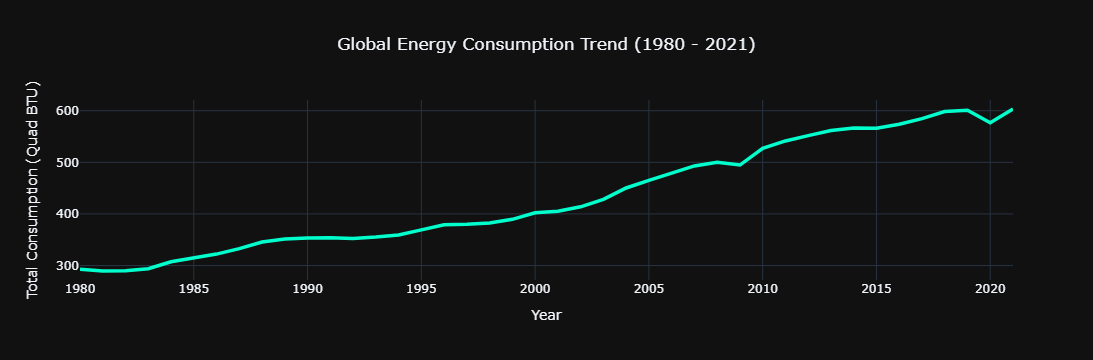

In [5]:
#Global Energy Consumption Trend (1980 - 2021)
global_consumption = df[years].sum().reset_index()
global_consumption.columns = ['Year', 'Total_Energy']
global_consumption['Year'] = global_consumption['Year'].astype(int)

fig_line = px.line(global_consumption, x='Year', y='Total_Energy',
                    title='Global Energy Consumption Trend (1980 - 2021)',
                    labels={'Total_Energy': 'Total Consumption (Quad BTU)', 'Year': 'Year'},
                    template='plotly_dark')

fig_line.update_traces(line=dict(color='#00ffcc', width=3.5))
fig_line.update_layout(title_x=0.5)
fig_line.show()

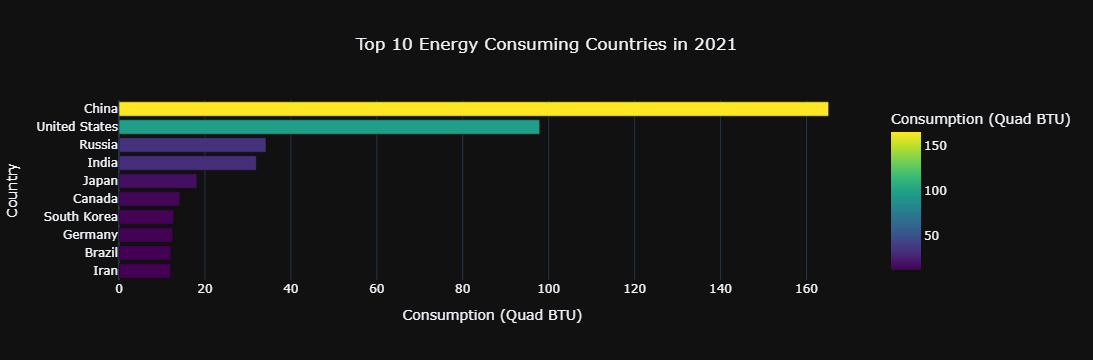

In [7]:
#Top 10 Energy Consuming Countries (2021)
top_10 = df.sort_values(by='2021', ascending=False).head(10)
fig_bar = px.bar(top_10, x='2021', y='Country', orientation='h',
                 title='Top 10 Energy Consuming Countries in 2021',
                 labels={'2021': 'Consumption (Quad BTU)', 'Country': 'Country'},
                 color='2021',
                 color_continuous_scale='Viridis',
                 template='plotly_dark')

fig_bar.update_layout(yaxis={'categoryorder':'total ascending'}, title_x=0.5)
fig_bar.show()

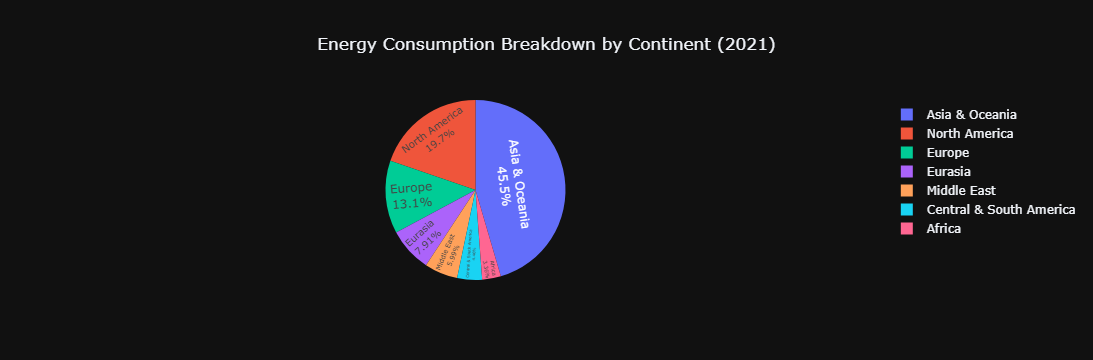

In [8]:
#Energy Consumption Share by Continent (2021)
continent_data = df.groupby('Continent')['2021'].sum().reset_index()

fig_pie = px.pie(continent_data, values='2021', names='Continent',
                 title='Energy Consumption Breakdown by Continent (2021)',
                 template='plotly_dark')

fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.update_layout(title_x=0.5)
fig_pie.show()

C:\Users\FreeComp\AppData\Local\Temp\ipykernel_9940\2241515931.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



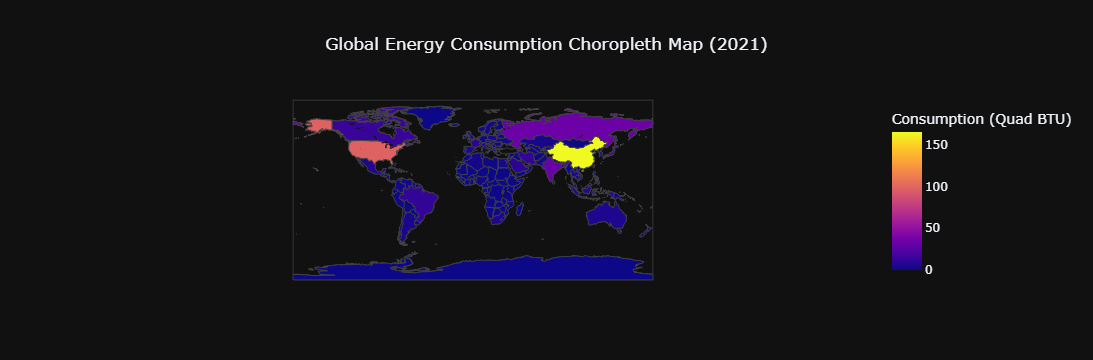

In [9]:
#Global Energy Consumption Map (2021)
fig_map = px.choropleth(df, locations="Country", locationmode='country names',
                       color="2021", hover_name="Country",
                       title="Global Energy Consumption Choropleth Map (2021)",
                       color_continuous_scale=px.colors.sequential.Plasma,
                       labels={'2021':'Consumption (Quad BTU)'},
                       template='plotly_dark')
fig_map.update_layout(title_x=0.5)
fig_map.show()

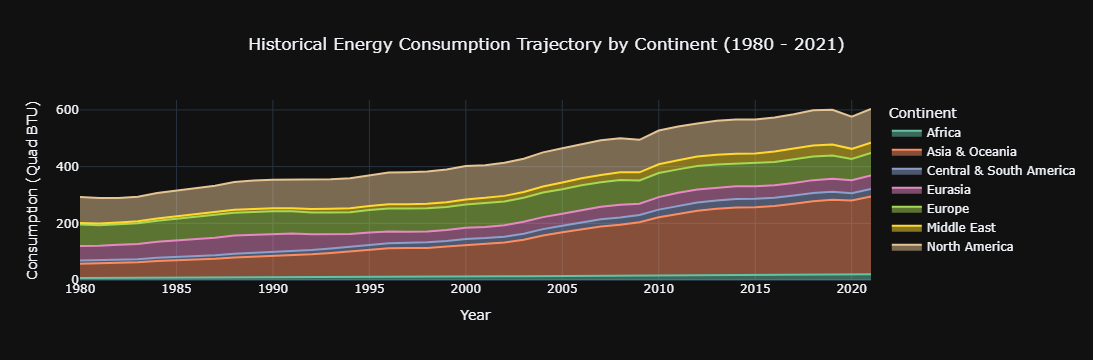

In [11]:
continent_time = df.groupby('Continent')[years].sum().stack().reset_index()
continent_time.columns = ['Continent', 'Year', 'Consumption']
continent_time['Year'] = continent_time['Year'].astype(int)

fig_area = px.area(continent_time, x='Year', y='Consumption', color='Continent',
                   title='Historical Energy Consumption Trajectory by Continent (1980 - 2021)',
                   labels={'Consumption': 'Consumption (Quad BTU)', 'Year': 'Year'},
                   template='plotly_dark',
                   color_discrete_sequence=px.colors.qualitative.Set2)
fig_area.update_layout(title_x=0.5)
fig_area.show()

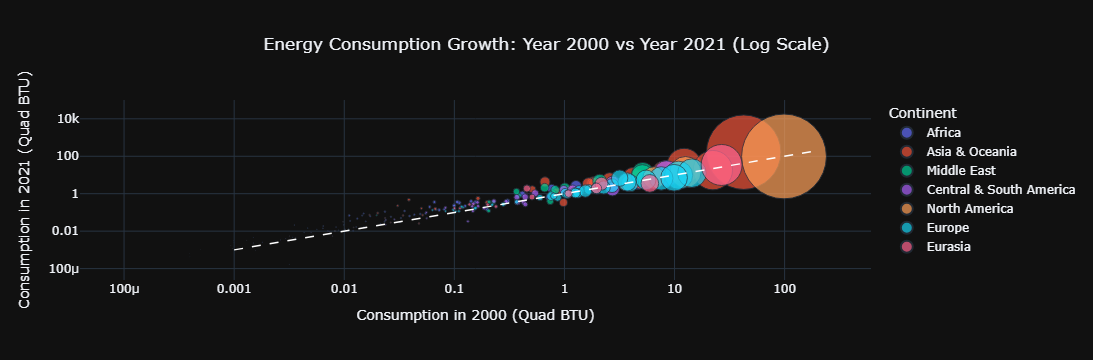

In [13]:
df['Total_Consumption'] = df[years].sum(axis=1)
df_filtered = df[(df['2000'] > 0) & (df['2021'] > 0)]
fig_scatter = px.scatter(df_filtered, 
                         x='2000', 
                         y='2021',
                         size='Total_Consumption', 
                         color='Continent',
                         hover_name='Country',
                         log_x=True, 
                         log_y=True,
                         title='Energy Consumption Growth: Year 2000 vs Year 2021 (Log Scale)',
                         labels={'2000': 'Consumption in 2000 (Quad BTU)', 
                                 '2021': 'Consumption in 2021 (Quad BTU)'},
                         size_max=60,
                         template='plotly_dark')
fig_scatter.add_shape(type="line",
                      x0=0.001, y0=0.001, x1=200, y1=200,
                      line=dict(color="White", width=1.5, dash="dash"))

fig_scatter.update_layout(title_x=0.5)
fig_scatter.show()